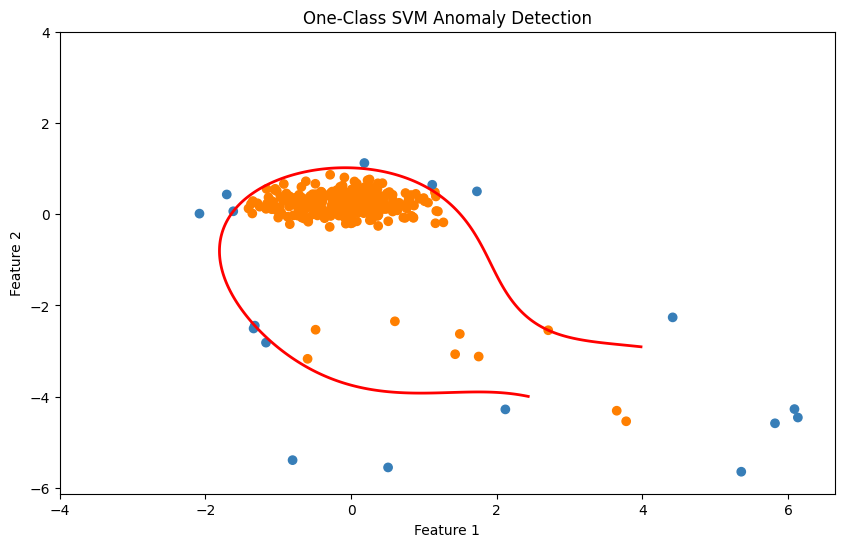

Number of anomalies detected: 17


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5, random_state=42)
outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X, outliers]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)

colors = np.array(['#377eb8', '#ff7f00'])
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color=colors[(y_pred + 1) // 2])

xx, yy = np.meshgrid(np.linspace(-4, 4, 500), np.linspace(-4, 4, 500))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')
plt.title("One-Class SVM Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

n_outliers = (y_pred == -1).sum()
print(f"Number of anomalies detected: {n_outliers}")